In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.dates as mdates
import plotly.graph_objects as go

from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

## Time-series Prediction (SARIMAX)

In [2]:
prediction_SARIMAX = pd.read_csv('/content/drive/MyDrive/COD_ML_Project/FINAL PREDICTION/forecasted_COD_final.csv',
                                   parse_dates = True)
prediction_SARIMAX = prediction_SARIMAX.rename(columns = {'Unnamed: 0': 'Datetime'})
prediction_SARIMAX = prediction_SARIMAX.set_index('Datetime')

In [3]:
prediction_SARIMAX.head(5)

,"Forecasted, COD"
Datetime,
2026-06-01,138.758440
2026-06-02,139.086393
2026-06-03,140.316180
2026-06-04,157.545265
2026-06-05,149.968376


# Laboratory Results

In [4]:
lab_result = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/FINAL PREDICTION/COD Laboratory Results.xlsx',
                       parse_dates = True).set_index('Date')

In [5]:
lab_result.head(5)

,Influent COD Value
Date,
2026-06-17,169
2026-06-19,171
2026-06-21,158
2026-06-23,160
2026-06-24,154


# Plotting

In [12]:
fig = go.Figure()

# Predicted COD Values using SARIMAX
fig.add_trace(go.Scatter(
    x=prediction_SARIMAX.index,
    y=prediction_SARIMAX['Forecasted, COD'],
    mode='lines',
    name='SARIMAX Forecast',
    line=dict(width=2)
))

# Laboratory Results
fig.add_trace(go.Scatter(
    x=lab_result.index,
    y=lab_result['Influent COD Value'],
    mode='lines+markers',
    name='Laboratory Results',
    marker=dict(size=8, color='purple', symbol='circle'),
    line=dict(width=2, dash='dot', color='black')
))

# Design Value
fig.add_hline(y=200, line_dash="dot", line_color="red", annotation_text="Design Value", annotation_position="bottom right")


fig.update_layout(
    title='SARIMAX VS Laboratory Results',
    xaxis_title='Datetime',
    yaxis_title='Predicted COD Values',
    hovermode='x unified'
)

# Show the plot
fig.show()

# Hypothesis

- Null Hypothesis (H₀): There is no statistically significant difference between the laboratory COD values and the predicted COD values.
- Alternative Hypothesis (H₁): There is a statistically significant difference between the laboratory COD values and the predicted COD values.
- Significance Level (α): 0.05

In [7]:
# Merging Laboratory Result and Predicted COD Values

prediction_SARIMAX.index = pd.to_datetime(prediction_SARIMAX.index).normalize()
lab_result.index = pd.to_datetime(lab_result.index).normalize()
df_lab_predicted = pd.merge(prediction_SARIMAX, lab_result, left_index=True, right_index=True, how='inner')

In [13]:
df_lab_predicted

,"Forecasted, COD",Influent COD Value
2026-06-17,171.608564,169
2026-06-19,176.473241,171
2026-06-21,163.480416,158
2026-06-23,154.247627,160
2026-06-24,150.889358,154
2026-06-27,175.114844,178
2026-06-29,177.362207,175
2026-07-01,150.769695,156
2026-07-06,159.822175,164
2026-07-12,156.143950,146


In [14]:
ttest=stats.ttest_ind(df_lab_predicted['Forecasted, COD'],df_lab_predicted['Influent COD Value'])
ttest_df = pd.Series(ttest)

index_ttest = {0: 't-statistic', 1: 'p-value'}
ttest_df = ttest_df.rename(index_ttest)
ttest_df


,0
t-statistic,0.105305
p-value,0.917298


Since the **p-value of 0.917 is greater than the significance level of 0.05, the null hypothesis is not rejected**. Therefore, there is no statistically significant difference between the predicted COD values and the laboratory analysis results, indicating that the **predictive model is statistically aligned with the laboratory measurements.**

# Bland-Altman Analysis

In [10]:
def bland_altman_analysis(df):

  difference = df['Forecasted, COD'] - df['Influent COD Value']
  mean = (df['Forecasted, COD'] + df['Influent COD Value']) / 2

  mean_differences = np.mean(difference)
  std_differences = np.std(difference)

  upper_limit = mean_differences + 1.96 * std_differences
  lower_limit = mean_differences - 1.96 * std_differences

  plt.figure(figsize=(10, 6))
  plt.scatter(mean, difference, alpha=0.5)
  plt.axhline(y=mean_differences, color='yellow', linestyle='-', label='Mean Difference')
  plt.axhline(y=upper_limit, color='red', linestyle=':', label='Upper Limit of Agreement')
  plt.axhline(y=lower_limit, color='red', linestyle=':', label='Lower Limit of Agreement')
  plt.xlabel('Mean of Measurements')
  plt.ylabel('Difference')
  plt.title('Bland-Altman Plot of Prediction VS Laboratory Result')
  plt.legend()
  plt.grid(True)
  plt.show()


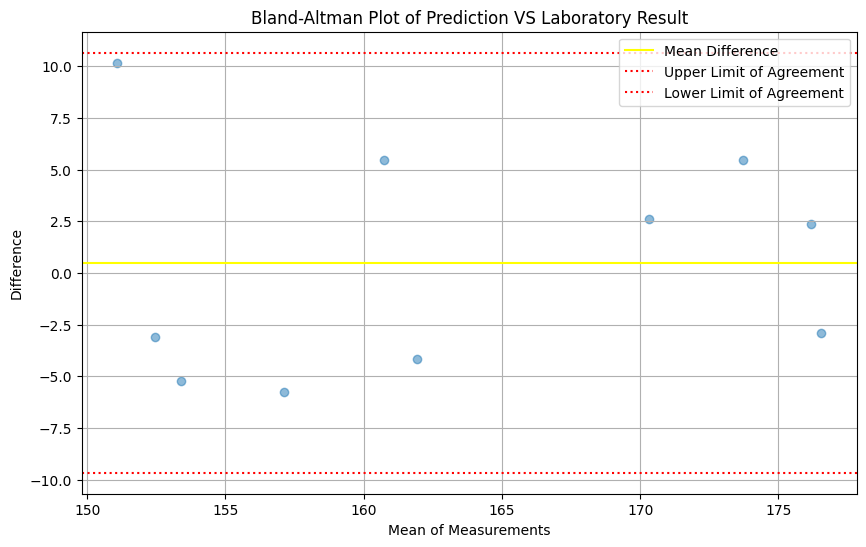

In [11]:
bland_altman_analysis(df_lab_predicted)

- The Bland-Altman Analysis indicated excellent relationship between the predicted and laboratory COD values.

- The mean difference was close to zero suggesting minimal error between the two methods.

- The observed differences fell within the upper and lower limits of agreement.